1. Import Necessary Libraries


In [2]:
# 1. Framework Utama (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

# 2. Pengolahan Gambar & Arsitektur Model
import torchvision
from torchvision import datasets, transforms, models

# 3. Pengolahan Data & Statistik
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 4. Visualisasi & Gambar
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# 5. Integrasi Kaggle & OS
import kagglehub
import os
import zipfile

# 6. Library Khusus Visualisasi Grad-CAM
# (Pastikan sudah install: pip install grad-cam)
!pip install grad-cam
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Library 'grad-cam' belum terinstall. Silakan jalankan: !pip install grad-cam")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=86363520a5d245ee6d90cf493ff5312b9c5e1f78b13540205343568e9dad8814
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


2. Load and Transform Data menggunakan kaggle

In [3]:
from google.colab import drive
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# --- STEP 1: MOUNT GOOGLE DRIVE ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Tentukan path folder utama (Sesuaikan jika nama folder berbeda)
data_dir = '/content/drive/MyDrive/APPLE_BANANA'

# --- STEP 2: DEFINISI TRANSFORMASI ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# --- STEP 3: FILTER KELAS & LOAD DATASET ---
selected_classes = ['apple_segar', 'apple_busuk', 'banana_segar', 'banana_busuk']
full_dataset = datasets.ImageFolder(data_dir)

# Mapping indeks kelas agar sesuai dengan folder di Drive
indices = [i for i, (path, label) in enumerate(full_dataset.samples)
           if full_dataset.classes[label] in selected_classes]

# --- STEP 4: SPLIT DATASET (70:15:15) ---
filtered_targets = [full_dataset.targets[i] for i in indices]

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=filtered_targets,
    random_state=42
)

val_targets = [full_dataset.targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=val_targets,
    random_state=42
)

# --- STEP 5: MEMBUAT SUBSET ---
train_dataset = Subset(datasets.ImageFolder(data_dir, transform=data_transforms['train']), train_idx)
val_dataset = Subset(datasets.ImageFolder(data_dir, transform=data_transforms['val_test']), val_idx)
test_dataset = Subset(datasets.ImageFolder(data_dir, transform=data_transforms['val_test']), test_idx)

# --- STEP 6: DEFINISI DATALOADER ---
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# --- STEP 7: HITUNG & TAMPILKAN DISTRIBUSI PER KELAS ---
def get_distribution(idx_list):
    dist = {cls: 0 for cls in selected_classes}
    for i in idx_list:
        cls_name = full_dataset.classes[full_dataset.targets[i]]
        dist[cls_name] += 1
    return dist

train_counts = get_distribution(train_idx)
val_counts = get_distribution(val_idx)
test_counts = get_distribution(test_idx)

print("\n" + "="*65)
print(f"{'NAMA KELAS':<20} | {'TRAIN':<10} | {'VAL':<10} | {'TEST':<10}")
print("-" * 65)
for cls in selected_classes:
    print(f"{cls:<20} | {train_counts[cls]:<10} | {val_counts[cls]:<10} | {test_counts[cls]:<10}")
print("="*65)

print(f"TOTAL DATASET: {len(indices)} Gambar")
print(f"Status: Berhasil memuat {len(selected_classes)} kelas.")

Mounted at /content/drive

NAMA KELAS           | TRAIN      | VAL        | TEST      
-----------------------------------------------------------------
apple_segar          | 280        | 60         | 60        
apple_busuk          | 280        | 60         | 60        
banana_segar         | 280        | 60         | 60        
banana_busuk         | 280        | 60         | 60        
TOTAL DATASET: 1600 Gambar
Status: Berhasil memuat 4 kelas.


3. Placing Data into a Dataframe


In [4]:
# Membuat list informasi file
all_images_info = []

# Iterasi melalui kelas yang ditemukan di folder dataset
for class_name in full_dataset.classes:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            all_images_info.append({
                'File_Path': os.path.join(class_path, img_name),
                'Label': class_name
            })

# Membuat Dataframe
df = pd.DataFrame(all_images_info)

# Menampilkan 5 data teratas dan distribusi kelas
print("--- 5 Data Teratas ---")
print(df.head())
print("\n--- Distribusi Jumlah Gambar per Kelas ---")
print(df['Label'].value_counts())

--- 5 Data Teratas ---
                                           File_Path        Label
0  /content/drive/MyDrive/APPLE_BANANA/apple_busu...  apple_busuk
1  /content/drive/MyDrive/APPLE_BANANA/apple_busu...  apple_busuk
2  /content/drive/MyDrive/APPLE_BANANA/apple_busu...  apple_busuk
3  /content/drive/MyDrive/APPLE_BANANA/apple_busu...  apple_busuk
4  /content/drive/MyDrive/APPLE_BANANA/apple_busu...  apple_busuk

--- Distribusi Jumlah Gambar per Kelas ---
Label
apple_busuk     400
apple_segar     400
banana_busuk    400
banana_segar    400
Name: count, dtype: int64


4. Visualizing images from the dataset


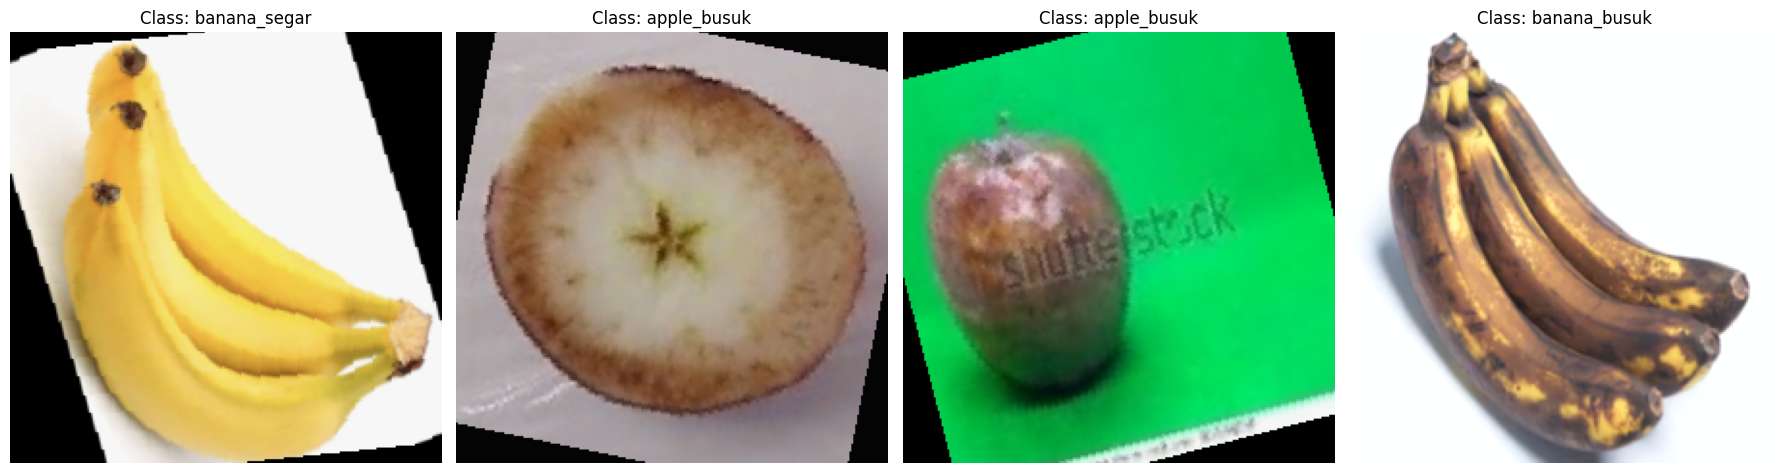

In [5]:
def visualize_dataset_samples(dataset, classes, n_images=4):
    # Mengatur ukuran figure
    plt.figure(figsize=(18, 6))

    # Mengambil sampel acak dari dataset
    indices = np.random.choice(len(dataset), n_images, replace=False)

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Proses Unnormalize: mengembalikan gambar ke rentang [0, 1]
        # ImageNet mean & std
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Konversi tensor ke numpy dan pindahkan channel ke belakang (H, W, C)
        image = image.permute(1, 2, 0).numpy()
        image = std * image + mean
        image = np.clip(image, 0, 1)

        # Plotting
        plt.subplot(1, n_images, i + 1)
        plt.imshow(image)
        plt.title(f"Class: {classes[label]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Memanggil fungsi untuk memvisualisasikan data dari train_dataset
# full_dataset.classes berisi daftar nama sayuran
visualize_dataset_samples(train_dataset, full_dataset.classes)

5. Computing Error Rate Analysis


In [6]:
def compute_error_analysis(y_true, y_pred):
    """
    Fungsi untuk menghitung Error Rate dan Accuracy secara akurat.
    Input berupa list atau array dari label asli (true) dan hasil prediksi (pred).
    """
    # Pastikan data dalam format numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Menghitung total data
    total_samples = len(y_true)

    # Menghitung jumlah prediksi yang salah
    incorrect_predictions = np.sum(y_true != y_pred)

    # Menghitung Error Rate
    error_rate = incorrect_predictions / total_samples

    # Menghitung Accuracy (sebagai pembanding)
    accuracy = 1 - error_rate

    return error_rate, accuracy

# Penjelasan Logika:
# Fungsi ini nantinya akan kita panggil setelah tahap 'Model Evaluation'
# untuk memverifikasi apakah kita sudah memenuhi syarat "Minimal Akurasi 80%"
# (atau dengan kata lain, Error Rate maksimal 0.20).
print("Fungsi Computing Error Rate Analysis telah didefinisikan.")

Fungsi Computing Error Rate Analysis telah didefinisikan.


6. Data Preprocessing


In [7]:
import torch

# 1. Menentukan Device (Pastikan GPU Aktif)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Status Device: {device}")
if device.type == 'cpu':
    print("PERINGATAN: Kamu menggunakan CPU. Training akan sangat lambat. Disarankan ganti ke GPU di settings.")

# 2. Mengambil Mapping Kelas dari Dataset yang sudah difilter
# Kita gunakan class_to_idx untuk memastikan urutan label
class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}
num_classes = len(selected_classes)

print(f"\nTotal Kelas: {num_classes}")
print(f"Mapping Kelas (Target): {class_to_idx}")

# 3. Sanity Check pada DataLoader
data_batch, label_batch = next(iter(train_loader))

print(f"\n--- Sanity Check ---")
print(f"Bentuk Tensor Gambar (Batch): {data_batch.shape}")
print(f"Bentuk Tensor Label (Batch): {label_batch.shape}")
print(f"Nilai Pixel (Min/Max): {data_batch.min():.2f} / {data_batch.max():.2f}")

# Simpan variabel penting untuk Step 7
print(f"\nSiap lanjut ke training dengan {num_classes} kelas.")

Status Device: cuda

Total Kelas: 4
Mapping Kelas (Target): {'apple_segar': 0, 'apple_busuk': 1, 'banana_segar': 2, 'banana_busuk': 3}

--- Sanity Check ---
Bentuk Tensor Gambar (Batch): torch.Size([32, 3, 224, 224])
Bentuk Tensor Label (Batch): torch.Size([32])
Nilai Pixel (Min/Max): -2.12 / 2.64

Siap lanjut ke training dengan 4 kelas.


7. Training the model

In [20]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def inisialisasi_eksperimen(lr_custom, optimizer_type="Adam"):
    """
    Fungsi untuk menyiapkan model dengan hyperparameter tertentu.
    lr_custom: Nilai Learning Rate yang ingin diuji.
    optimizer_type: Jenis optimizer (default: Adam).
    """
    # 1. Inisialisasi Model (Pretrained EfficientNet-B0)
    model_exp = models.efficientnet_b0(weights='IMAGENET1K_V1')

    # 2. Modifikasi Output Layer sesuai jumlah kelas (4 kelas)
    in_features = model_exp.classifier[1].in_features
    model_exp.classifier[1] = nn.Linear(in_features, num_classes)

    # Pindahkan ke GPU/CPU
    model_exp = model_exp.to(device)

    # 3. Loss Function
    criterion_exp = nn.CrossEntropyLoss()

    # 4. Optimizer (Disini kita menerapkan eksperimen Learning Rate)
    if optimizer_type == "Adam":
        optimizer_exp = optim.Adam(model_exp.parameters(), lr=lr_custom)
    elif optimizer_type == "SGD":
        optimizer_exp = optim.SGD(model_exp.parameters(), lr=lr_custom, momentum=0.9)

    # Persiapan variabel history baru untuk setiap eksperimen
    history_exp = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Konfigurasi Eksperimen Siap: LR={lr_custom}, Optimizer={optimizer_type}")
    return model_exp, criterion_exp, optimizer_exp, history_exp

# --- CONTOH CARA MENJALANKAN DI STEP 7B ---
# Misal kamu ingin mencoba Learning Rate yang berbeda:
# model, criterion, optimizer, history = inisialisasi_eksperimen(lr_custom=0.001)

In [21]:
import time

# 1. Tentukan Skenario Eksperimen (Ubah nilai LR di sini untuk eksperimen)
# Contoh: 0.001 (Standar), 0.01 (Tinggi), atau 0.0001 (Rendah)
LR_EKSPERIMEN = 0.001
model, criterion, optimizer, history = inisialisasi_eksperimen(lr_custom=LR_EKSPERIMEN)

# 2. Konfigurasi Epoch
num_epochs = 50
HIJAU = '\033[92m'
RESET = '\033[0m'

print(f"\nMemulai Training Skenario LR: {LR_EKSPERIMEN}...")

for epoch in range(num_epochs):
    start_time = time.time()

    # --- PHASE TRAINING ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    total_batches = len(train_loader)

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Tampilan Progres Persentase (Warna Hijau)
        percent = (i + 1) / total_batches * 100
        print(f"\r{HIJAU}Epoch [{epoch+1}/{num_epochs}] Progress: {percent:.1f}%{RESET}", end="")

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # --- PHASE VALIDASI ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # Simpan riwayat untuk visualisasi
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Tampilkan ringkasan setiap epoch
    durasi = time.time() - start_time
    print(f"\nSelesai Epoch {epoch+1} ({int(durasi)}s) | "
          f"Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f}")
    print("-" * 65)

print(f"\n{HIJAU}Eksperimen LR {LR_EKSPERIMEN} Selesai!{RESET}")

Konfigurasi Eksperimen Siap: LR=0.001, Optimizer=Adam

Memulai Training Skenario LR: 0.001...
Epoch [1/50] Progress: 100.0%
Selesai Epoch 1 (17s) | Loss: 0.1997 Acc: 0.9357 | Val Loss: 0.4481 Val Acc: 0.9125
-----------------------------------------------------------------
Epoch [2/50] Progress: 100.0%
Selesai Epoch 2 (14s) | Loss: 0.0648 Acc: 0.9821 | Val Loss: 0.0705 Val Acc: 0.9750
-----------------------------------------------------------------
Epoch [3/50] Progress: 100.0%
Selesai Epoch 3 (14s) | Loss: 0.0642 Acc: 0.9821 | Val Loss: 0.1616 Val Acc: 0.9667
-----------------------------------------------------------------
Epoch [4/50] Progress: 100.0%
Selesai Epoch 4 (14s) | Loss: 0.0411 Acc: 0.9911 | Val Loss: 0.0263 Val Acc: 0.9875
-----------------------------------------------------------------
Epoch [5/50] Progress: 100.0%
Selesai Epoch 5 (14s) | Loss: 0.0594 Acc: 0.9777 | Val Loss: 0.0193 Val Acc: 0.9917
-----------------------------------------------------------------
Epoch 

8. Model Evaluation

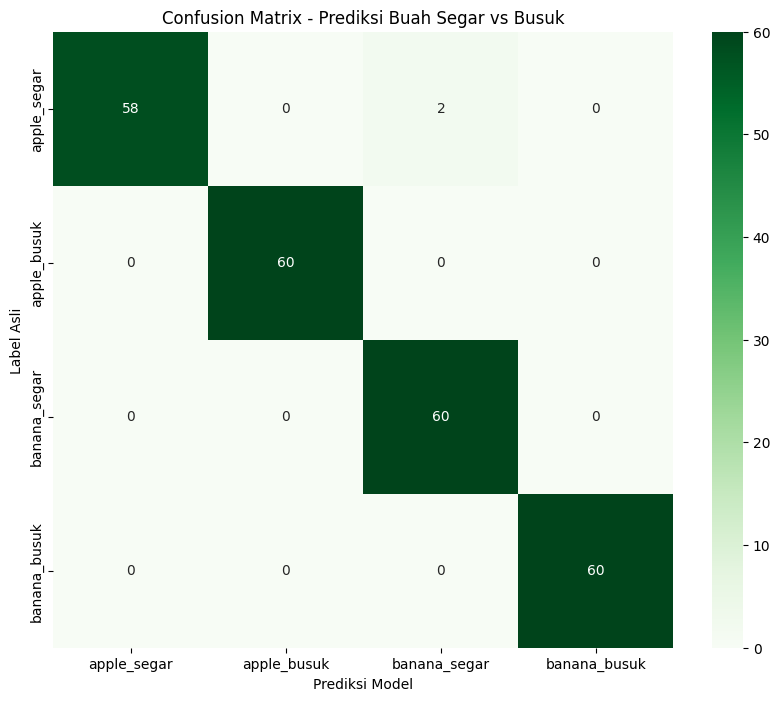


Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

 apple_segar       1.00      0.97      0.98        60
 apple_busuk       1.00      1.00      1.00        60
banana_segar       0.97      1.00      0.98        60
banana_busuk       1.00      1.00      1.00        60

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

def show_confusion_matrix():
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Membuat Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_df = pd.DataFrame(cm, index=selected_classes, columns=selected_classes)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix - Prediksi Buah Segar vs Busuk')
    plt.ylabel('Label Asli')
    plt.xlabel('Prediksi Model')
    plt.show()

    # Classification Report
    print("\nLaporan Klasifikasi Detail:")
    print(classification_report(all_labels, all_preds, target_names=selected_classes))

show_confusion_matrix()

Saving resep-setup-pisang-kepok-kuning-2_169.jpeg to resep-setup-pisang-kepok-kuning-2_169.jpeg


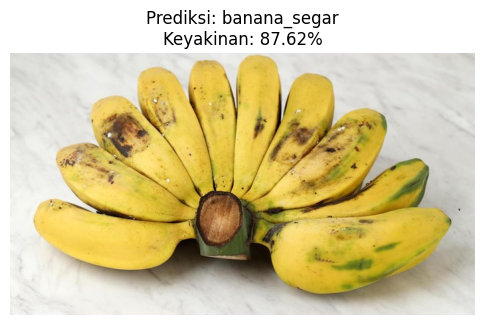

Hasil Analisis: Gambar ini dideteksi sebagai 'banana_segar' dengan tingkat keyakinan 87.62%


In [16]:
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- TAHAP 1: FUNGSI PREDIKSI ---
def predict_uploaded_image(model, class_names):
    # Mengunggah file dari komputer kamu
    uploaded = files.upload()

    for fn in uploaded.keys():
        # Load gambar
        path = fn
        img = Image.open(path).convert('RGB')

        # Samakan transformasi dengan data validasi/test kamu
        # Resize 224x224 dan Normalisasi ImageNet
        preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        input_tensor = preprocess(img).unsqueeze(0).to(device)

        # Jalankan Prediksi
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            # Hitung probabilitas (persentase keyakinan)
            probs = F.softmax(output, dim=1)
            conf, preds = torch.max(probs, 1)

        # Tampilkan Hasil
        predicted_class = class_names[preds.item()]
        confidence_score = conf.item() * 100

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Prediksi: {predicted_class}\nKeyakinan: {confidence_score:.2f}%")
        plt.axis('off')
        plt.show()

        print(f"Hasil Analisis: Gambar ini dideteksi sebagai '{predicted_class}' dengan tingkat keyakinan {confidence_score:.2f}%")

# --- TAHAP 2: JALANKAN ---
# Panggil fungsi ini untuk mencoba
predict_uploaded_image(model, selected_classes)

9. Visualizing loss curves

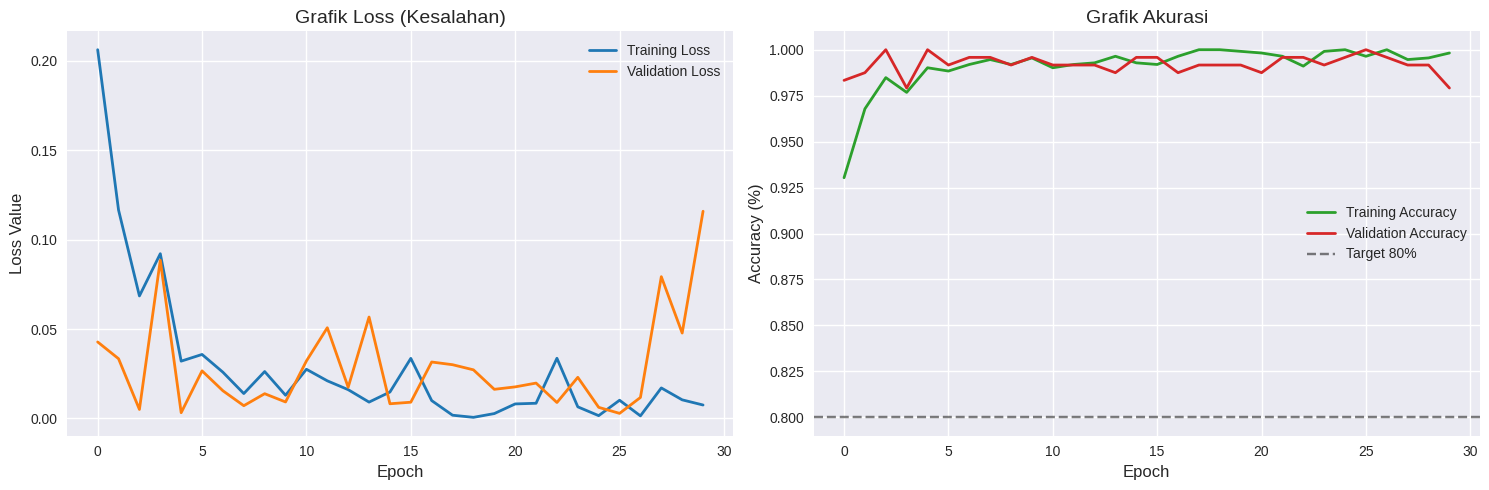

In [17]:
# Mengatur gaya visualisasi
plt.style.use('seaborn-v0_8') # atau 'ggplot' jika seaborn tidak tersedia
plt.figure(figsize=(15, 5))

# --- Grafik 1: Loss Curve ---
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Grafik Loss (Kesalahan)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend()
plt.grid(True)

# --- Grafik 2: Accuracy Curve ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy', color='#2ca02c', lw=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='#d62728', lw=2)
plt.axhline(y=0.8, color='black', linestyle='--', alpha=0.5, label='Target 80%')
plt.title('Grafik Akurasi', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

10. Making predictions on the Test Data

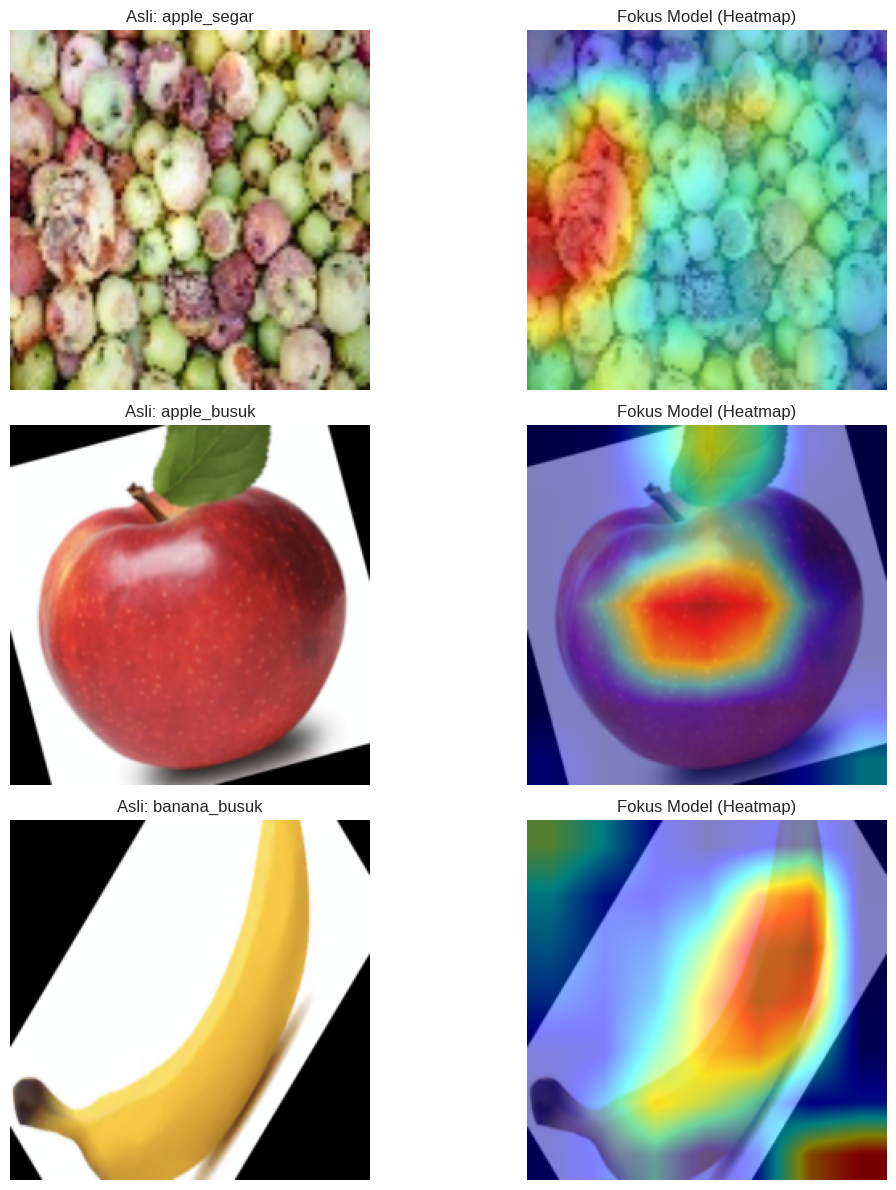

In [19]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Pilih layer target
# Untuk EfficientNet-B0, model.features[-1] adalah Conv2d terakhir sebelum Global Average Pooling
target_layers = [model.features[-1]]

# 2. Inisialisasi GradCAM
# Kita tambahkan use_cuda agar otomatis mendeteksi GPU jika tersedia
cam = GradCAM(model=model, target_layers=target_layers)

def visualize_gradcam(n_images=3):
    model.eval()
    plt.figure(figsize=(12, 4 * n_images))

    # Ambil sampel secara acak agar hasil visualisasi bervariasi
    indices = np.random.choice(len(test_dataset), n_images, replace=False)

    for i, idx in enumerate(indices):
        img_tensor, label_idx = test_dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # Tentukan target kelas
        targets = [ClassifierOutputTarget(label_idx)]

        # Generate heatmap
        # Kita bungkus dalam try-except untuk menghindari error 'reshape' pada beberapa versi torch
        try:
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
            grayscale_cam = grayscale_cam[0, :]
        except Exception as e:
            print(f"Kendala pada Grad-CAM: {e}")
            continue

        # Proses denormalisasi gambar asli (Background)
        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)

        # Gabungkan heatmap dengan gambar asli
        visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)

        # --- Plotting ---
        # Gambar Asli
        plt.subplot(n_images, 2, 2*i + 1)
        plt.imshow(img_show)
        plt.title(f"Asli: {selected_classes[label_idx]}")
        plt.axis('off')

        # Gambar Grad-CAM
        plt.subplot(n_images, 2, 2*i + 2)
        plt.imshow(visualization)
        plt.title(f"Fokus Model (Heatmap)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Pastikan variabel 'device' dan 'selected_classes' sudah terdefinisi dari sel sebelumnya
visualize_gradcam(n_images=3)

EXPERIMEN HYPERPARAMETER

In [22]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import time

# --- 1. KONFIGURASI HYPERPARAMETER EKSPERIMEN ---
LR_EKSPERIMEN = 0.005
BATCH_SIZE_EKSPERIMEN = 64
EPOCHS_EKSPERIMEN = 50 # Sesuai permintaan sebelumnya

# --- 2. UPDATE DATALOADER ---
# Kita buat loader baru khusus untuk eksperimen ini
train_loader_exp = DataLoader(train_dataset, batch_size=BATCH_SIZE_EKSPERIMEN, shuffle=True)
val_loader_exp = DataLoader(val_dataset, batch_size=BATCH_SIZE_EKSPERIMEN, shuffle=False)

# --- 3. INISIALISASI MODEL BARU ---
print(f"Menyiapkan Model Eksperimen (LR: {LR_EKSPERIMEN}, Batch: {BATCH_SIZE_EKSPERIMEN})...")
model_exp = models.efficientnet_b0(weights='IMAGENET1K_V1')
model_exp.classifier[1] = nn.Linear(model_exp.classifier[1].in_features, num_classes)
model_exp = model_exp.to(device)

criterion_exp = nn.CrossEntropyLoss()
optimizer_exp = optim.Adam(model_exp.parameters(), lr=LR_EKSPERIMEN)

# Persiapan variabel history khusus eksperimen
history_exp = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# --- 4. TRAINING LOOP EKSPERIMEN ---
HIJAU = '\033[92m'
RESET = '\033[0m'

print(f"Memulai Training Eksperimen...")

for epoch in range(EPOCHS_EKSPERIMEN):
    start_time = time.time()

    # FASE TRAINING
    model_exp.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    total_batches = len(train_loader_exp)

    for i, (inputs, labels) in enumerate(train_loader_exp):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_exp.zero_grad()
        outputs = model_exp(inputs)
        loss = criterion_exp(outputs, labels)
        loss.backward()
        optimizer_exp.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Progres Persentase Hijau
        percent = (i + 1) / total_batches * 100
        print(f"\r{HIJAU}Epoch [{epoch+1}/{EPOCHS_EKSPERIMEN}] Progress: {percent:.1f}%{RESET}", end="")

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # FASE VALIDASI
    model_exp.eval()
    running_val_loss, correct_val = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader_exp:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_exp(inputs)
            v_loss = criterion_exp(outputs, labels)
            running_val_loss += v_loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / len(val_dataset)

    # Simpan History
    history_exp['train_loss'].append(epoch_train_loss)
    history_exp['val_loss'].append(epoch_val_loss)
    history_exp['train_acc'].append(epoch_train_acc)
    history_exp['val_acc'].append(epoch_val_acc)

    durasi = time.time() - start_time
    print(f"\nSelesai Epoch {epoch+1} ({int(durasi)}s) | Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

print(f"\n{HIJAU}Eksperimen Hyperparameter Selesai!{RESET}")

Menyiapkan Model Eksperimen (LR: 0.005, Batch: 64)...
Memulai Training Eksperimen...
Epoch [1/50] Progress: 100.0%
Selesai Epoch 1 (21s) | Loss: 0.4022 Acc: 0.8643 | Val Acc: 0.4250
Epoch [2/50] Progress: 100.0%
Selesai Epoch 2 (19s) | Loss: 0.2014 Acc: 0.9411 | Val Acc: 0.9667
Epoch [3/50] Progress: 100.0%
Selesai Epoch 3 (19s) | Loss: 0.1913 Acc: 0.9446 | Val Acc: 0.9250
Epoch [4/50] Progress: 100.0%
Selesai Epoch 4 (19s) | Loss: 0.0786 Acc: 0.9812 | Val Acc: 0.9167
Epoch [5/50] Progress: 100.0%
Selesai Epoch 5 (18s) | Loss: 0.0842 Acc: 0.9741 | Val Acc: 0.9875
Epoch [6/50] Progress: 100.0%
Selesai Epoch 6 (20s) | Loss: 0.0514 Acc: 0.9857 | Val Acc: 0.9333
Epoch [7/50] Progress: 100.0%
Selesai Epoch 7 (19s) | Loss: 0.0508 Acc: 0.9848 | Val Acc: 0.9625
Epoch [8/50] Progress: 100.0%
Selesai Epoch 8 (18s) | Loss: 0.0230 Acc: 0.9938 | Val Acc: 0.9375
Epoch [9/50] Progress: 100.0%
Selesai Epoch 9 (19s) | Loss: 0.0322 Acc: 0.9911 | Val Acc: 0.9875
Epoch [10/50] Progress: 100.0%
Selesai Epo

Sedang mengevaluasi model pada data test...


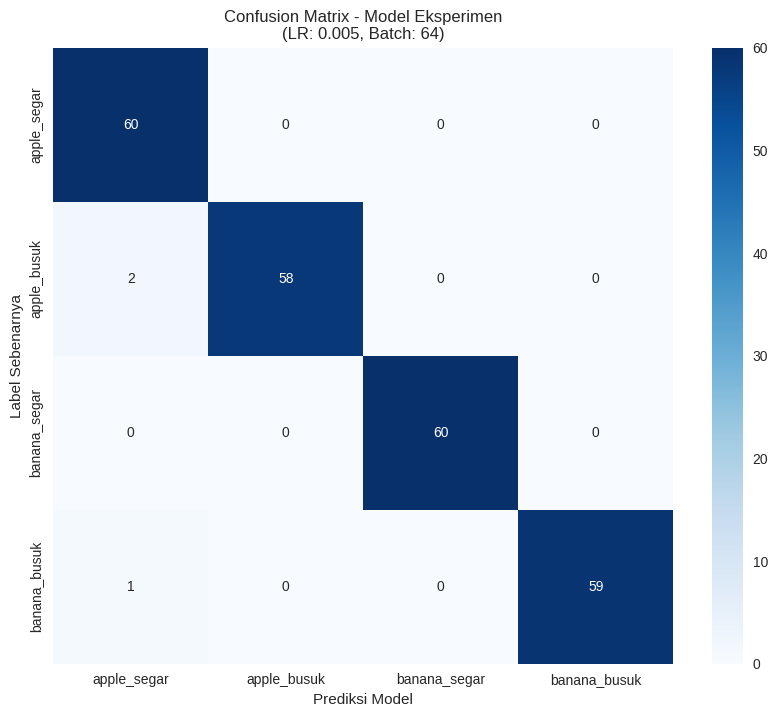


LAPORAN KLASIFIKASI DETAIL
              precision    recall  f1-score   support

 apple_segar       0.95      1.00      0.98        60
 apple_busuk       1.00      0.97      0.98        60
banana_segar       1.00      1.00      1.00        60
banana_busuk       1.00      0.98      0.99        60

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def evaluasi_model_eksperimen(model_to_test, loader_to_use, class_names):
    """
    Fungsi untuk mengevaluasi model dan menampilkan Confusion Matrix serta Akurasi detail.
    """
    model_to_test.eval()
    all_preds = []
    all_labels = []

    print("Sedang mengevaluasi model pada data test...")

    with torch.no_grad():
        for inputs, labels in loader_to_use:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_to_test(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Membuat Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # 2. Plotting Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues') # Warna biru untuk membedakan dengan sebelumnya
    plt.title(f'Confusion Matrix - Model Eksperimen\n(LR: 0.005, Batch: 64)')
    plt.ylabel('Label Sebenarnya')
    plt.xlabel('Prediksi Model')
    plt.show()

    # 3. Laporan Klasifikasi (Akurasi, Precision, Recall, F1-Score)
    print("\n" + "="*30)
    print("LAPORAN KLASIFIKASI DETAIL")
    print("="*30)
    print(classification_report(all_labels, all_preds, target_names=class_names))

# --- EKSEKUSI ---
# Gunakan model_exp dan test_loader yang sudah ada
evaluasi_model_eksperimen(model_exp, test_loader, selected_classes)

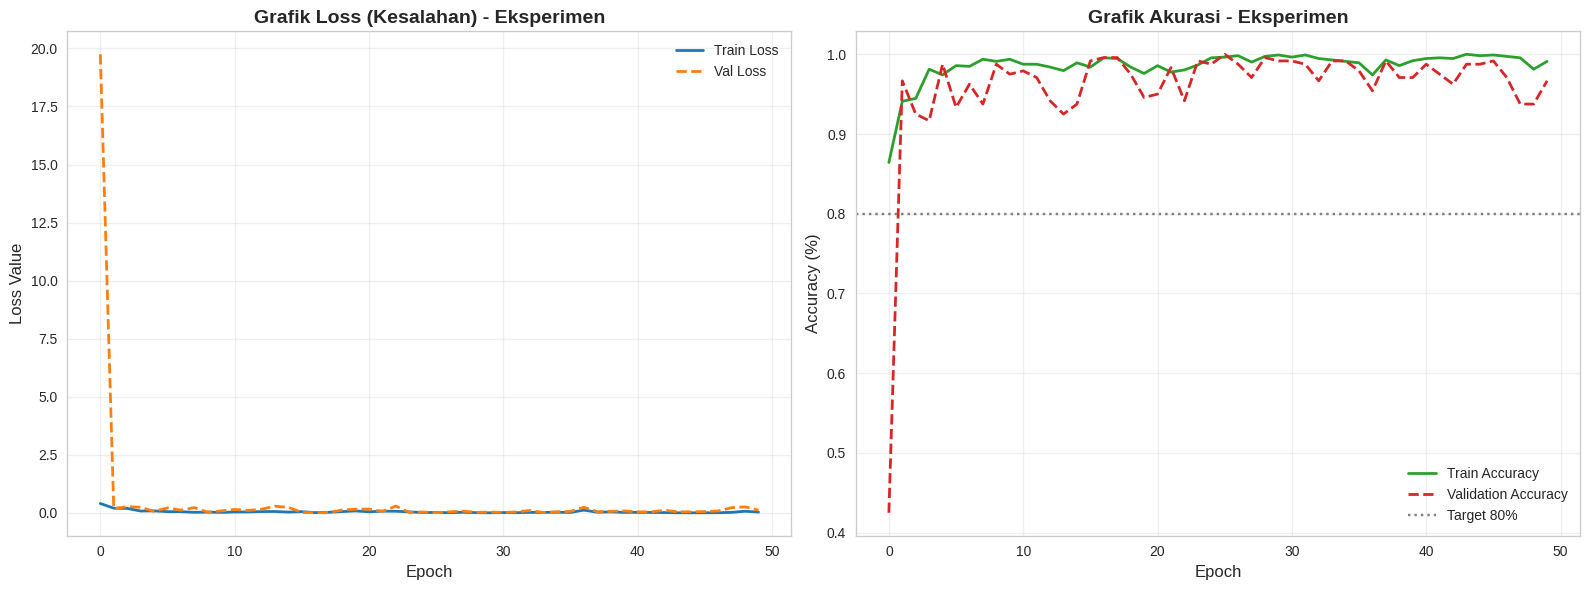

In [24]:
import matplotlib.pyplot as plt

def plot_hasil_eksperimen(hist):
    # Mengatur gaya visualisasi
    plt.style.use('seaborn-v0_8-whitegrid') # Gaya bersih dan profesional
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 1. GRAFIK LOSS ---
    ax1.plot(hist['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    ax1.plot(hist['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    ax1.set_title('Grafik Loss (Kesalahan) - Eksperimen', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss Value', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # --- 2. GRAFIK AKURASI ---
    ax2.plot(hist['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
    ax2.plot(hist['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2, linestyle='--')
    ax2.axhline(y=0.80, color='gray', linestyle=':', label='Target 80%') # Garis target
    ax2.set_title('Grafik Akurasi - Eksperimen', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    # Memastikan layout tidak tumpang tindih
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Memanggil fungsi menggunakan data history_exp dari Step 11
plot_hasil_eksperimen(history_exp)